In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
sns.set()

In [2]:
df=pd.read_csv("HR_Data.csv")

In [3]:
print("Shape: ", df.shape)
print("\nMissing Values: ")
print(df.isnull().sum())
print("\n Data types: ")
print(df.dtypes)
print("\n Basic stats: ")
print(df.describe())

Shape:  (1470, 35)

Missing Values: 
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
Yea

In [4]:
print(df.shape)

(1470, 35)


## Handling Redundancy

In [5]:
df=df.drop(columns=["EmployeeCount","Over18","StandardHours"])
print(df.shape)

(1470, 32)


## Label Encoding

In [6]:
df["Attrition"]=df["Attrition"].map({"Yes":1, "No": 0})

In [7]:
df["Attrition"].value_counts()



0    1233
1     237
Name: Attrition, dtype: int64

In [8]:
df["Attrition"].dtype

dtype('int64')

In [9]:
df["OverTime"]=df["OverTime"].map({"Yes":1, "No": 0})

In [10]:
df["OverTime"].value_counts()

0    1054
1     416
Name: OverTime, dtype: int64

In [11]:
df["OverTime"].dtype

dtype('int64')

In [12]:
df["Gender"]=df["Gender"].map({"Male":1,"Female":0})

In [13]:
df["Gender"].value_counts()


1    882
0    588
Name: Gender, dtype: int64

In [14]:
df["Gender"].dtype

dtype('int64')

## Ordinal encoding

In [15]:
df["BusinessTravel"].value_counts()

Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: BusinessTravel, dtype: int64

In [16]:
df["BusinessTravel"]=df["BusinessTravel"].map({"Non-Travel":0,"Travel_Frequently":2,"Travel_Rarely":1})

In [17]:
df["BusinessTravel"].value_counts()

1    1043
2     277
0     150
Name: BusinessTravel, dtype: int64

In [18]:
df["BusinessTravel"].dtype

dtype('int64')

In [19]:
print(df.select_dtypes(include='object').columns.tolist())

['Department', 'EducationField', 'JobRole', 'MaritalStatus']


## One Hot Encoding

In [20]:
df=pd.get_dummies(df, columns=['Department', 'EducationField', 'JobRole', 'MaritalStatus'], drop_first = True)

In [21]:
df.shape

(1470, 45)

In [22]:
print(df.columns.tolist())


['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [23]:
df.describe(include="all")

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,1.086395,802.485714,9.192517,2.912925,1024.865306,2.721769,0.600000,65.891156,...,0.035374,0.176190,0.069388,0.098639,0.054422,0.198639,0.221769,0.056463,0.457823,0.319728
std,9.135373,0.367863,0.532170,403.509100,8.106864,1.024165,602.024335,1.093082,0.490065,20.329428,...,0.184786,0.381112,0.254199,0.298279,0.226925,0.399112,0.415578,0.230891,0.498387,0.466530
min,18.000000,0.000000,0.000000,102.000000,1.000000,1.000000,1.000000,1.000000,0.000000,30.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,1.000000,465.000000,2.000000,2.000000,491.250000,2.000000,0.000000,48.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,36.000000,0.000000,1.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,1.000000,66.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,43.000000,0.000000,1.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,1.000000,83.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,60.000000,1.000000,2.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,1.000000,100.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [24]:
print(df[['MonthlyIncome', 'Age', 'DistanceFromHome']].describe())

       MonthlyIncome          Age  DistanceFromHome
count    1470.000000  1470.000000       1470.000000
mean     6502.931293    36.923810          9.192517
std      4707.956783     9.135373          8.106864
min      1009.000000    18.000000          1.000000
25%      2911.000000    30.000000          2.000000
50%      4919.000000    36.000000          7.000000
75%      8379.000000    43.000000         14.000000
max     19999.000000    60.000000         29.000000


In [25]:
df=df.drop(columns=['EmployeeNumber'])

In [26]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,1102,1,2,2,0,94,3,...,0,0,0,0,0,0,1,0,0,1
1,49,0,2,279,8,1,3,1,61,2,...,0,0,0,0,0,1,0,0,1,0
2,37,1,1,1373,2,2,4,1,92,2,...,0,1,0,0,0,0,0,0,0,1
3,33,0,2,1392,3,4,4,0,56,3,...,0,0,0,0,0,1,0,0,1,0
4,27,0,1,591,2,1,1,1,40,3,...,0,1,0,0,0,0,0,0,1,0


In [27]:
cols_to_scale = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
                 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
                 'PercentSalaryHike', 'TotalWorkingYears', 
                 'TrainingTimesLastYear', 'YearsAtCompany', 
                 'YearsInCurrentRole', 'YearsSinceLastPromotion', 
                 'YearsWithCurrManager']

print(df[cols_to_scale].describe())


               Age    DailyRate  DistanceFromHome   HourlyRate  MonthlyIncome  \
count  1470.000000  1470.000000       1470.000000  1470.000000    1470.000000   
mean     36.923810   802.485714          9.192517    65.891156    6502.931293   
std       9.135373   403.509100          8.106864    20.329428    4707.956783   
min      18.000000   102.000000          1.000000    30.000000    1009.000000   
25%      30.000000   465.000000          2.000000    48.000000    2911.000000   
50%      36.000000   802.000000          7.000000    66.000000    4919.000000   
75%      43.000000  1157.000000         14.000000    83.750000    8379.000000   
max      60.000000  1499.000000         29.000000   100.000000   19999.000000   

        MonthlyRate  NumCompaniesWorked  PercentSalaryHike  TotalWorkingYears  \
count   1470.000000         1470.000000        1470.000000        1470.000000   
mean   14313.103401            2.693197          15.209524          11.279592   
std     7117.786044        

## Feature Scaling

In [28]:
scale= StandardScaler()
print(df[cols_to_scale].describe().round(2))
df[cols_to_scale]=scale.fit_transform(df[cols_to_scale])

           Age  DailyRate  DistanceFromHome  HourlyRate  MonthlyIncome  \
count  1470.00    1470.00           1470.00     1470.00        1470.00   
mean     36.92     802.49              9.19       65.89        6502.93   
std       9.14     403.51              8.11       20.33        4707.96   
min      18.00     102.00              1.00       30.00        1009.00   
25%      30.00     465.00              2.00       48.00        2911.00   
50%      36.00     802.00              7.00       66.00        4919.00   
75%      43.00    1157.00             14.00       83.75        8379.00   
max      60.00    1499.00             29.00      100.00       19999.00   

       MonthlyRate  NumCompaniesWorked  PercentSalaryHike  TotalWorkingYears  \
count      1470.00             1470.00            1470.00            1470.00   
mean      14313.10                2.69              15.21              11.28   
std        7117.79                2.50               3.66               7.78   
min        20

In [29]:
print(df[cols_to_scale].describe().round(2))

           Age  DailyRate  DistanceFromHome  HourlyRate  MonthlyIncome  \
count  1470.00    1470.00           1470.00     1470.00        1470.00   
mean     -0.00       0.00              0.00        0.00          -0.00   
std       1.00       1.00              1.00        1.00           1.00   
min      -2.07      -1.74             -1.01       -1.77          -1.17   
25%      -0.76      -0.84             -0.89       -0.88          -0.76   
50%      -0.10      -0.00             -0.27        0.01          -0.34   
75%       0.67       0.88              0.59        0.88           0.40   
max       2.53       1.73              2.44        1.68           2.87   

       MonthlyRate  NumCompaniesWorked  PercentSalaryHike  TotalWorkingYears  \
count      1470.00             1470.00            1470.00            1470.00   
mean          0.00                0.00               0.00              -0.00   
std           1.00                1.00               1.00               1.00   
min          

In [30]:
df.to_csv('hr_cleaned.csv', index=False)
print("Saved successfully!")
print("Final shape:", df.shape)

Saved successfully!
Final shape: (1470, 44)


# EDA

<Axes: xlabel='OverTime', ylabel='count'>

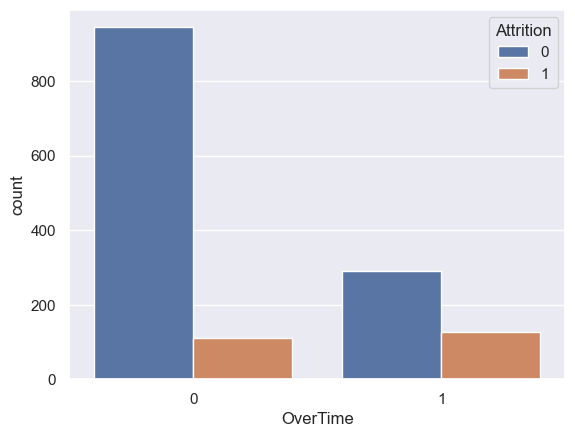

In [31]:
sns.countplot(x="OverTime", hue= "Attrition", data=df)

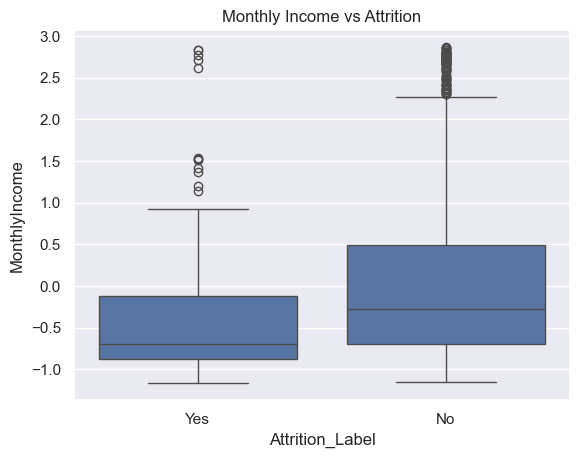

In [32]:
df['Attrition_Label'] = df['Attrition'].map({1:'Yes', 0:'No'})

sns.boxplot(x='Attrition_Label', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.show()

<Axes: xlabel='JobSatisfaction', ylabel='percent'>

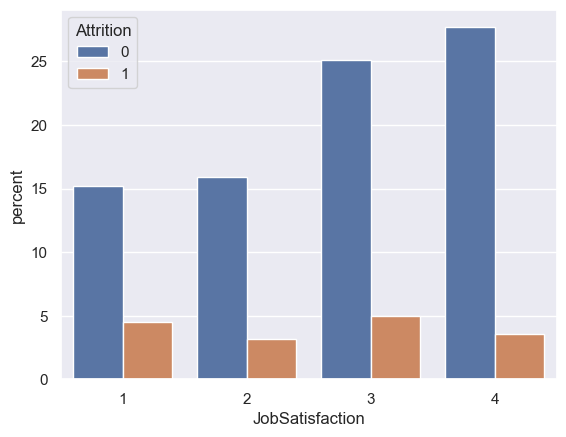

In [33]:
sns.countplot(x="JobSatisfaction", hue="Attrition", stat="percent",data=df)

In [36]:
df_viz = pd.read_csv('HR_Data.csv')
df_model = df

<Axes: xlabel='Age', ylabel='Count'>

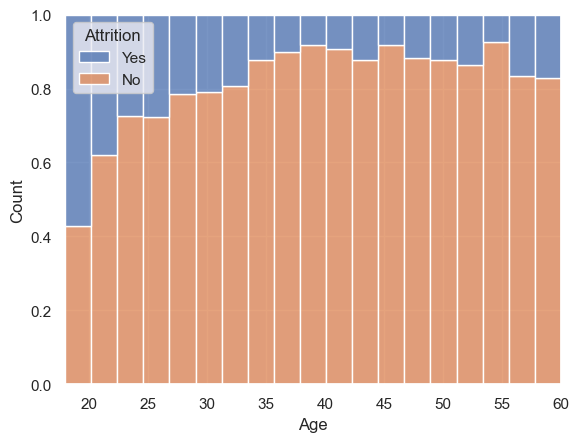

In [37]:
sns.histplot(x="Age", hue="Attrition", data=df_viz, multiple="fill")

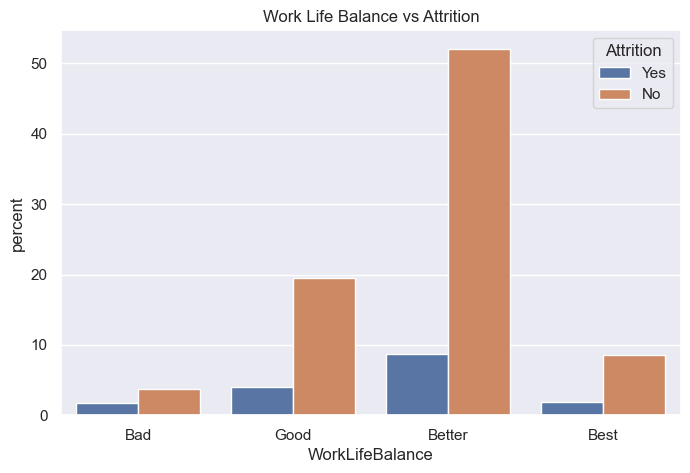

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df_viz, stat="percent")
plt.xticks([0,1,2,3], ["Bad","Good","Better","Best"])
plt.title('Work Life Balance vs Attrition')
plt.show()

In [39]:
df_viz["WorkLifeBalance"].describe()

count    1470.000000
mean        2.761224
std         0.706476
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         4.000000
Name: WorkLifeBalance, dtype: float64

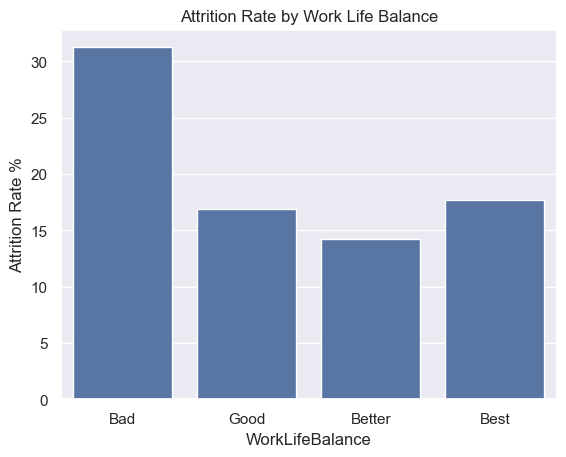

In [40]:
# Calculate attrition rate WITHIN each WLB group
wlb = df_viz.groupby('WorkLifeBalance')['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).reset_index()
wlb.columns = ['WorkLifeBalance', 'AttritionRate']
wlb['WorkLifeBalance'] = wlb['WorkLifeBalance'].map({1:'Bad', 2:'Good', 3:'Better', 4:'Best'})

sns.barplot(x='WorkLifeBalance', y='AttritionRate', data=wlb)
plt.title('Attrition Rate by Work Life Balance')
plt.ylabel('Attrition Rate %')
plt.show()

C:\Users\manee\AppData\Local\Temp\ipykernel_14232\10506652.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_viz.corr(), annot=False, fmt='0.2f', cmap='coolwarm', center=0)


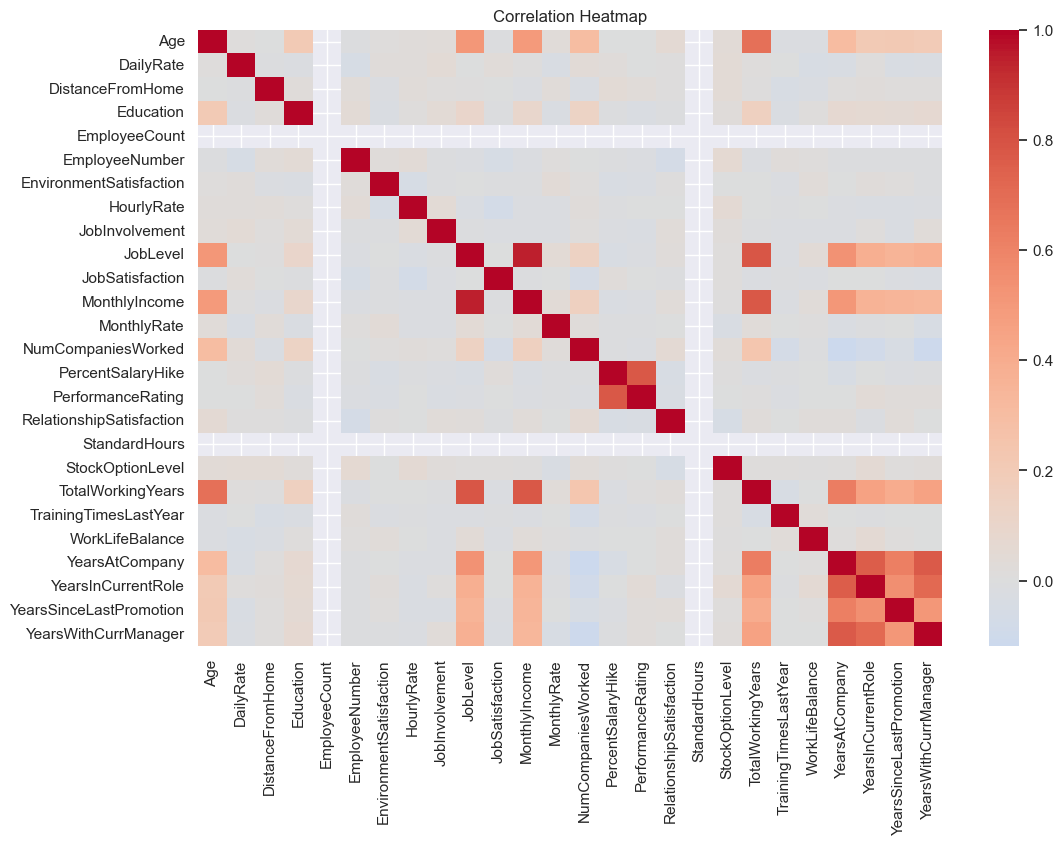

In [41]:
plt.figure(figsize=(12,8))
sns.heatmap(df_viz.corr(), annot=False, fmt='0.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [42]:
attrition_corr = df.corr()['Attrition'].sort_values(ascending=False)
print(attrition_corr)

Attrition                            1.000000
OverTime                             0.246118
MaritalStatus_Single                 0.175419
JobRole_Sales Representative         0.157234
BusinessTravel                       0.127006
JobRole_Laboratory Technician        0.098290
Department_Sales                     0.080855
DistanceFromHome                     0.077924
EducationField_Technical Degree      0.069355
EducationField_Marketing             0.055781
NumCompaniesWorked                   0.043494
JobRole_Human Resources              0.036215
Gender                               0.029453
JobRole_Sales Executive              0.019774
MonthlyRate                          0.015170
PerformanceRating                    0.002889
JobRole_Research Scientist          -0.000360
HourlyRate                          -0.006846
PercentSalaryHike                   -0.013478
EducationField_Other                -0.017898
Education                           -0.031373
EducationField_Life Sciences      

C:\Users\manee\AppData\Local\Temp\ipykernel_14232\2510815961.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  attrition_corr = df.corr()['Attrition'].sort_values(ascending=False)


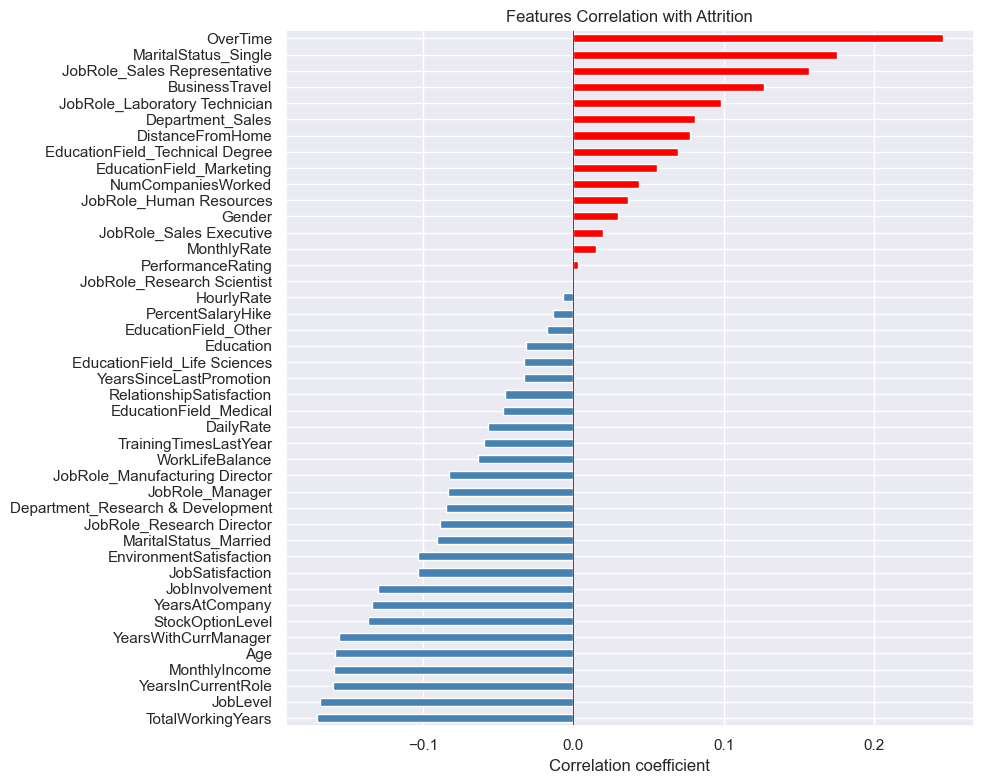

In [43]:
plt.figure(figsize=(10,8))
attrition_corr.drop('Attrition').sort_values().plot(kind='barh', color=['red' if x>0 else 'steelblue' for x in attrition_corr.drop('Attrition').sort_values()])
plt.title('Features Correlation with Attrition')
plt.xlabel('Correlation coefficient')
plt.axvline(x=0, color='black',linewidth=0.5)
plt.tight_layout()
plt.show()

## Training the model

In [44]:
X= df.drop(columns=['Attrition', 'Attrition_Label'])
y=df['Attrition']

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X_train,X_test,y_train,y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1176, 43)
X_test shape: (294, 43)
y_train shape: (1176,)
y_test shape: (294,)


In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:
lr=LogisticRegression()
lr.fit(X_train,y_train)

C:\Users\manee\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [50]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [51]:
y_pred=lr.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.891156462585034


In [52]:
from sklearn.metrics import classification_report

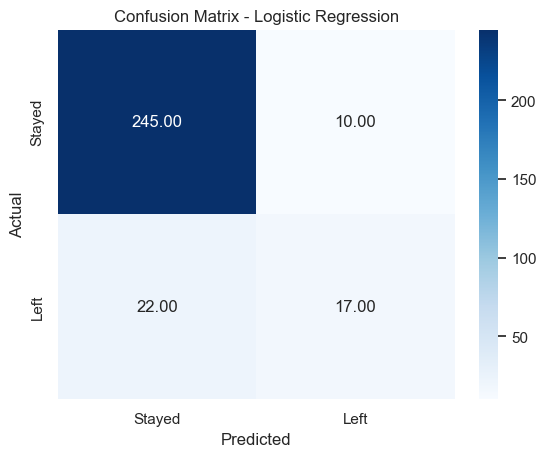

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       255
           1       0.63      0.44      0.52        39

    accuracy                           0.89       294
   macro avg       0.77      0.70      0.73       294
weighted avg       0.88      0.89      0.88       294



In [53]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,fmt='0.2f',cmap="Blues",xticklabels=["Stayed","Left"], yticklabels=["Stayed","Left"])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred))

In [54]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


## Applying SMOTE

In [55]:
from imblearn.over_sampling import SMOTE

In [56]:
smote=SMOTE(random_state=42)
X_train_smote, y_train_smote=smote.fit_resample(X_train,y_train)
print("\n Before SMOTE: ",y_train.value_counts())
print("\n After SMOTE: ",y_train_smote.value_counts())


 Before SMOTE:  0    978
1    198
Name: Attrition, dtype: int64

 After SMOTE:  0    978
1    978
Name: Attrition, dtype: int64


In [57]:
lr=LogisticRegression()
lr.fit(X_train_smote,y_train_smote)

C:\Users\manee\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [58]:
ypred1=lr.predict(X_test)
print(accuracy_score(y_test,ypred1))

0.8707482993197279


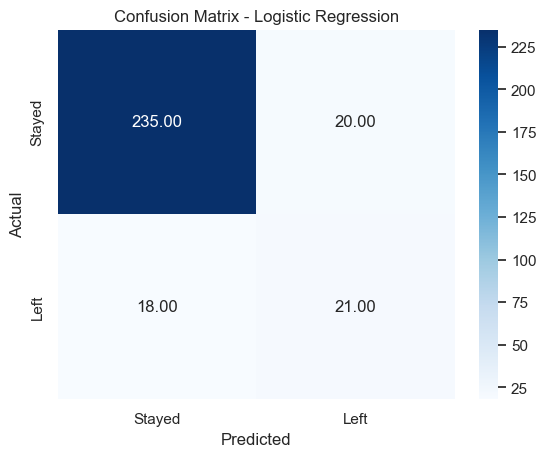

              precision    recall  f1-score   support

           0       0.93      0.92      0.93       255
           1       0.51      0.54      0.53        39

    accuracy                           0.87       294
   macro avg       0.72      0.73      0.73       294
weighted avg       0.87      0.87      0.87       294



In [59]:
cm=confusion_matrix(y_test,ypred1)
sns.heatmap(cm, annot=True,fmt='0.2f',cmap="Blues",xticklabels=["Stayed","Left"], yticklabels=["Stayed","Left"])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, ypred1))

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(X_train_smote,y_train_smote)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [61]:
y_preddt=dt.predict(X_test)
print(accuracy_score(y_test,y_preddt))
print(classification_report(y_test,y_preddt))

0.7074829931972789
              precision    recall  f1-score   support

           0       0.89      0.76      0.82       255
           1       0.19      0.36      0.25        39

    accuracy                           0.71       294
   macro avg       0.54      0.56      0.53       294
weighted avg       0.79      0.71      0.74       294



In [62]:
for depth in [3, 4, 5, 6, 7, 8, 10]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_smote, y_train_smote)
    y_pred_dt = dt.predict(X_test)
    recall = classification_report(y_test, y_pred_dt, output_dict=True)['1']['recall']
    print(f"max_depth={depth}, Recall={recall:.2f}")

max_depth=3, Recall=0.44
max_depth=4, Recall=0.31
max_depth=5, Recall=0.36
max_depth=6, Recall=0.28
max_depth=7, Recall=0.28
max_depth=8, Recall=0.33
max_depth=10, Recall=0.33


In [63]:
from sklearn.svm import SVC
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC()
}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    recall = classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} → Accuracy: {accuracy:.2f}, Recall: {recall:.2f}") 

Logistic Regression → Accuracy: 0.87, Recall: 0.54
Decision Tree → Accuracy: 0.76, Recall: 0.31


C:\Users\manee\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest → Accuracy: 0.89, Recall: 0.28
SVM → Accuracy: 0.88, Recall: 0.51


## SHAP Analysis

In [64]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [65]:
import shap

In [66]:
explainer = shap.LinearExplainer(lr, X_train_smote)
shap_values = explainer.shap_values(X_test)

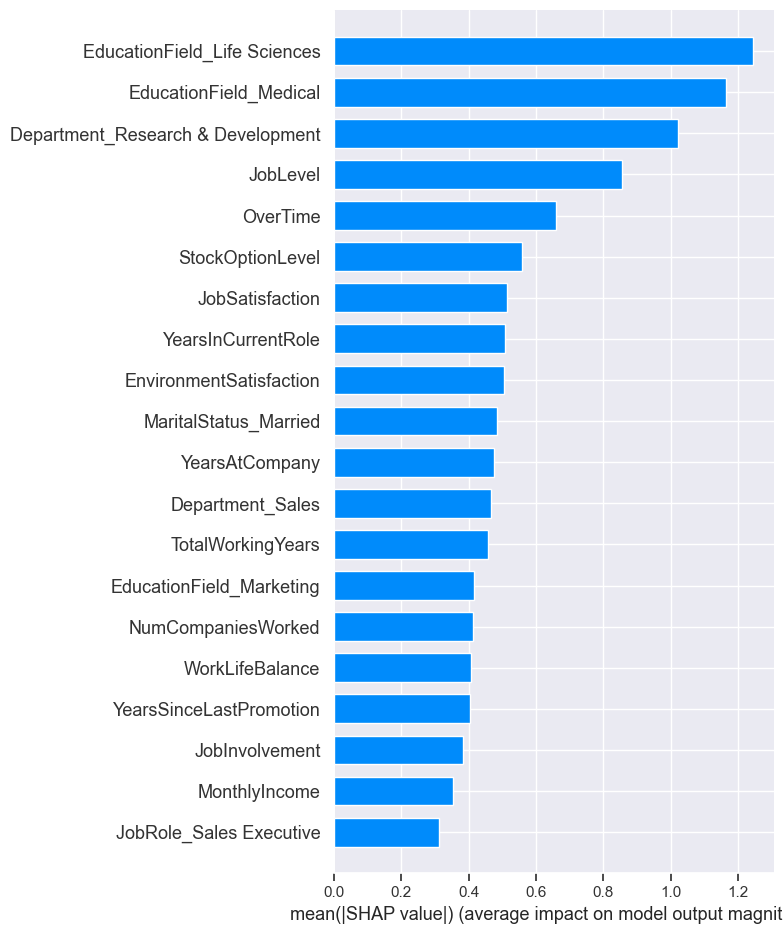

In [67]:
shap.summary_plot(shap_values, X_test, 
                  feature_names=X_test.columns, 
                  plot_type='bar')

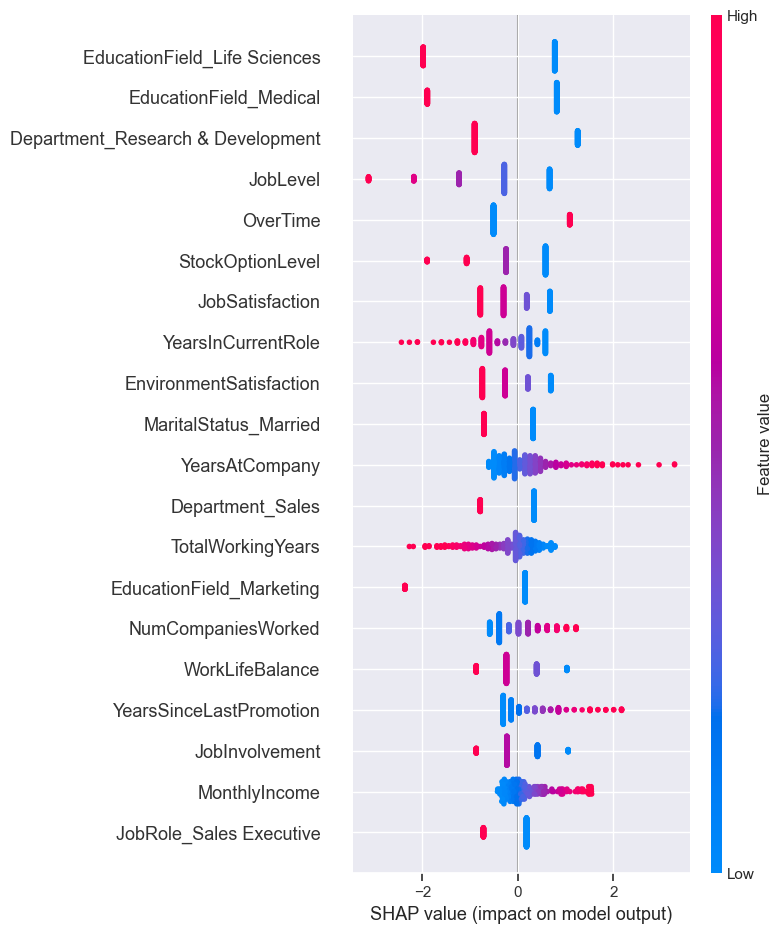

In [68]:
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

In [69]:
# New employee data
new_employee = X_test.iloc[0]  # take one test employee
# Predict probability of leaving
probability = lr.predict_proba(new_employee.values.reshape(1,-1))
print(f"Probability of staying: {probability[0][0]:.2%}")
print(f"Probability of leaving: {probability[0][1]:.2%}")

Probability of staying: 87.25%
Probability of leaving: 12.75%


C:\Users\manee\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [70]:
# Test on first 5 employees
for i in range(5):
    emp = X_test.iloc[i].values.reshape(1,-1)
    prob = lr.predict_proba(emp)[0][1]
    print(f"Employee {i+1}: {prob:.2%} chance of leaving")

Employee 1: 12.75% chance of leaving
Employee 2: 1.38% chance of leaving
Employee 3: 68.96% chance of leaving
Employee 4: 2.37% chance of leaving
Employee 5: 3.15% chance of leaving


C:\Users\manee\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\manee\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\manee\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\manee\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\manee\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


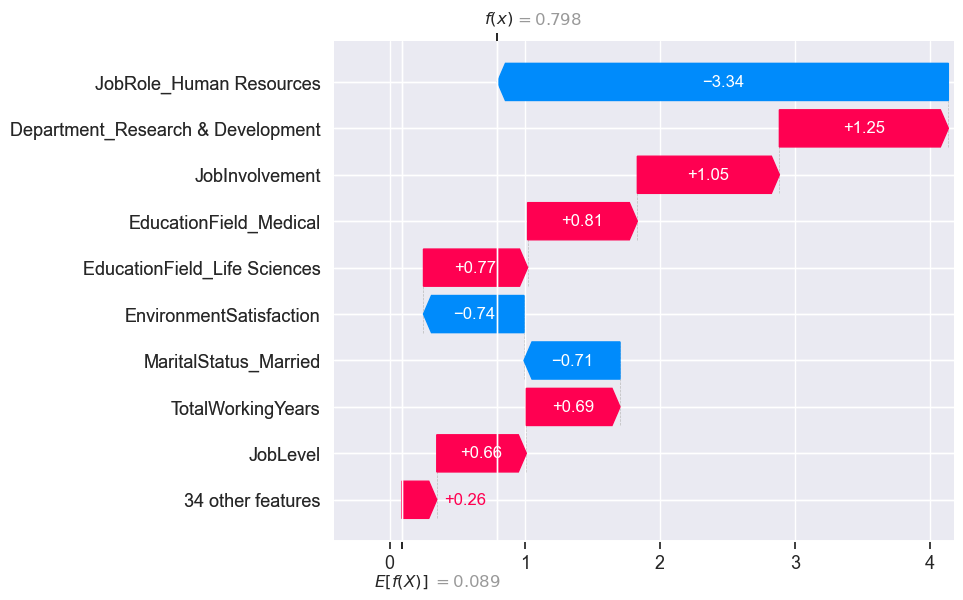

[[ 0.02802578 -0.02593841  0.11064388  0.46633283  0.13753424 -0.74456412
   0.02658261 -0.00986445  1.0519218   0.66320937 -0.30098774 -0.39263266
  -0.03253923 -0.3894719  -0.51057063 -0.01380445  0.0912897  -0.1022031
  -0.24781546  0.69371924  0.11899315 -0.24041972 -0.50112165  0.57585241
  -0.3068206   0.30578598  1.25140761  0.33787383  0.77093636  0.15104984
   0.81286575  0.13333419  0.12161312 -3.33935126  0.03582665  0.0430354
   0.07254536  0.02124404  0.17956194  0.18056158  0.04411989 -0.710887
   0.15223874]]


In [71]:
# Explain Employee 3's prediction
employee_3 = X_test.iloc[2].values.reshape(1,-1)

shap_values_emp3 = explainer.shap_values(X_test.iloc[2:3])

shap.waterfall_plot(shap.Explanation(
    values=shap_values_emp3[0],
    base_values=explainer.expected_value,
    feature_names=X_test.columns.tolist()
))
print(shap_values_emp3)

In [73]:
import pickle

# Save model
pickle.dump(lr, open('model.pkl', 'wb'))

# Save scaler
pickle.dump(scale, open('scaler.pkl', 'wb'))

# Save cleaned data
df.to_csv('hr_cleaned.csv', index=False)

print("All files saved!")

All files saved!


In [74]:
pip install streamlit

     ---------------------------------------- 9.2/9.2 MB 16.8 MB/s eta 0:00:00
     ------------------------------------- 440.0/440.0 kB 13.4 MB/s eta 0:00:00
     ------------------------------------- 212.5/212.5 kB 12.6 MB/s eta 0:00:00
     --------------------------------------- 27.3/27.3 MB 12.8 MB/s eta 0:00:00
     -------------------------------------- 114.4/114.4 kB 6.9 MB/s eta 0:00:00
     ---------------------------------------- 72.8/72.8 kB 4.2 MB/s eta 0:00:00
     ---------------------------------------- 44.6/44.6 kB 2.3 MB/s eta 0:00:00
     --------------------------------------- 11.3/11.3 MB 18.2 MB/s eta 0:00:00
     ------------------------------------- 178.7/178.7 kB 11.2 MB/s eta 0:00:00
     ---------------------------------------- 71.3/71.3 kB 2.0 MB/s eta 0:00:00
     ---------------------------------------- 86.2/86.2 kB 2.4 MB/s eta 0:00:00
     ------------------------------------- 797.0/797.0 kB 16.7 MB/s eta 0:00:00
     ------------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-server 1.23.4 requires anyio<4,>=3.1.0, but you have anyio 4.13.0 which is incompatible.
